In [ ]:
import collections
import os

import pysam
import matplotlib
import matplotlib.font_manager as fm
import pandas as pd
import scanpy as sc

fm.fontManager.addfont('/work/magroup/skrieger/Arial.ttf')
matplotlib.rcParams['font.size'] = 16.0
matplotlib.rcParams['font.family'] = 'sans-serif'
matplotlib.rcParams['font.sans-serif'] = ['Arial']

os.makedirs('figure_panels', exist_ok=True)
sc.settings.figdir = 'figure_panels'

In [1]:
# Define genomic coordinates for Nrg1 gene and its isoform2 unique region.
chrom = "chr8"
# Entire gene region (mm10): 31,818,028 to 32,884,254 (1-based inclusive)
gene_start = 31818028   # 1-based start
gene_end   = 32884254   # 1-based end

# Isoform2 unique region: 32,009,110 to 32,884,254 (1-based inclusive)
iso2_unique_start = 32009110
iso2_unique_end   = 32884254

# Convert unique region to 0-based coordinates for pysam:
iso2_unique_start_0 = iso2_unique_start - 1
iso2_unique_end_0 = iso2_unique_end  # pysam's fetch end is exclusive

# Open the BAM file (assumed to be coordinate-sorted and indexed)
bam_file = "publication_figure_data/misar-seq/paired_endAligned.sortedByCoord.out.bam"
bam = pysam.AlignmentFile(bam_file, "rb")

cell_iso2_counts = collections.Counter()
cell_noniso2_counts = collections.Counter()

# Fetch all reads mapping to the entire Nrg1 gene region.
for read in bam.fetch(chrom, gene_start - 1, gene_end):
    if read.is_unmapped:
        continue
    try:
        cell_barcode = read.get_tag("CB")
    except KeyError:
        continue

    # Get read's alignment positions (0-based)
    read_start = read.reference_start
    read_end = read.reference_end

    # Check for overlap with isoform2 unique region.
    # If any base of the read overlaps the unique region, assign it as isoform2.
    if read_end > iso2_unique_start_0 and read_start < iso2_unique_end_0:
        cell_iso2_counts[cell_barcode] += 1
    else:
        cell_noniso2_counts[cell_barcode] += 1

bam.close()

In [2]:
ad = sc.read('publication_figure_data/misar-seq/cellOracle_misar_mouse_processed_E15_5-S2_scale.h5ad')

In [3]:
iso2_series = pd.Series(cell_iso2_counts)
noniso2_series = pd.Series(cell_noniso2_counts)

# ad.obs.index has barcodes like "AAACCTGAGAAACCAT-1". We strip the "-1" and map to our Series.
ad.obs['iso2_counts'] = (
    ad.obs.index.str.replace(r'-1$', '', regex=True)
    .map(iso2_series)
    .fillna(0)
    .astype(int)
)
ad.obs['noniso2_counts'] = (
    ad.obs.index.str.replace(r'-1$', '', regex=True)
    .map(noniso2_series)
    .fillna(0)
    .astype(int)
)

/tmp/ipykernel_3177/3144634893.py:1: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(ad, spot_size=1, color=['iso2_counts'], vmax=150, frameon=False, title='Nrg1 type II', save='Panel_H_left.svg')


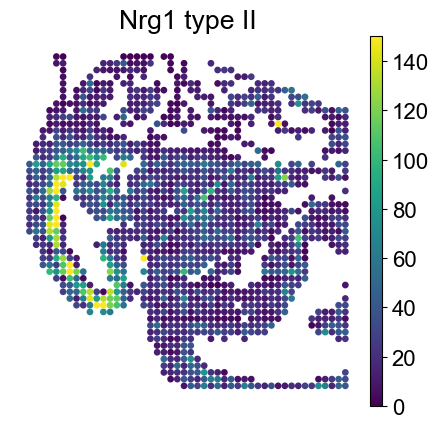

In [5]:
sc.pl.spatial(ad, spot_size=1, color=['iso2_counts'], vmax=150, frameon=False, title='Nrg1 type II', save='Panel_2H_left.svg')

/tmp/ipykernel_3177/834155898.py:1: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(ad, spot_size=1, color=['noniso2_counts'], vmax=20, frameon=False, title='Nrg1 other types', save='Panel_H_right.svg')


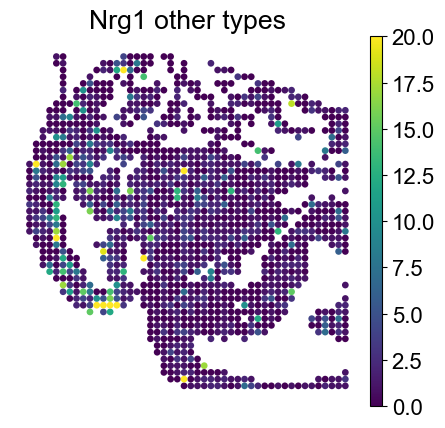

In [6]:
sc.pl.spatial(ad, spot_size=1, color=['noniso2_counts'], vmax=20, frameon=False, title='Nrg1 other types', save='Panel_2H_right.svg')